# Import 

In [85]:
import h5py
from seisbench.models import CRED,EQTransformer,PhaseNet,GPD,OBSTransformer
import numpy as np
from seisbench.data import WaveformDataset
import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt
from obspy import Stream, Trace
from tqdm import  tqdm 
import matplotlib.transforms as mtransforms
import nest_asyncio
nest_asyncio.apply()

from sklearn.metrics import recall_score, balanced_accuracy_score

def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn


def try_treshold(prob,labels):
    VecR = []
    VecA = []
    px= np.arange(0.1,1,0.01)
    for p in  px : 
        #Score = np.sum([ip>p for ip in prob])/len(prob)*100
        VecR.append(recall_score(labels,[ip>p for ip in prob]))
        VecA.append(balanced_accuracy_score(labels,[ip>p for ip in prob]))
    return np.array(VecR),px,np.array(VecA)

def try_SNR(prob,SNR,labels):
    VecR = []
    VecA = []
    Nv= []
    px= list(np.arange(0,8,1))
    SNR = np.array(SNR)
    SNR[SNR>px[-1]] = px[-2]
    classe = np.array([ip>0.50 for ip in prob])
    for k in range(len(px)-1) : 
        iisnr=np.where( (SNR>=px[k]) & (SNR<px[k+1]))
        #Score = np.sum( [ip>0.50 for ip in prob[iisnr]] )/(len(prob[iisnr]) + 1e-11)*100 *(np.nan,1)[len(prob[ii])>0]
        Nv  = Nv+[len(iisnr[0])]
        if Nv[-1]>0:
            VecR.append(recall_score(labels[iisnr],classe[iisnr]))
            VecA.append(balanced_accuracy_score(labels[iisnr],classe[iisnr]))
        else:
            VecR.append(0)
            VecA.append(0)
    return np.array(VecR),np.array(px), Nv,np.array(VecA)
    
def plotprobs(prob,labels):
    bins=np.arange(0,1.1,0.1)
    selection = np.where(labels==0)
    recp , px , accp = try_treshold(1-prob[selection],[1]*len(selection[0]))
    figdist = plt.figure(figsize=(18,5))
    plt.subplot(1,3,1)
    plt.hist(1-prob[selection],bins=bins,cumulative=False,density=False,color='k')
    plt.ylabel('Number')
    plt.xlabel('Noise Probability')
    plt.twinx()
    plt.plot(px,accp,color='r',ls='-',lw=4)
    plt.ylabel('Recall/Accuracy')
    plt.title('Noise class Probablity distribution')
    plt.subplot(1,3,2)
    selection = np.where(labels==1)
    recp , px , accp = try_treshold(prob[selection],[1]*len(selection[0]))
    plt.hist(prob[selection],bins=bins,cumulative=False,density=False,color='k')
    plt.ylabel('Number')
    plt.xlabel('Signal Probability')
    plt.twinx()
    plt.plot(px,accp,color='r',ls='-',lw=4)
    plt.ylabel('Recall/Accuracy')
    plt.title('Signal class Probablity distribution')

    plt.subplot(1,3,3)
    recp , px , accp = try_treshold(prob,labels)
    plt.hist([prob[i] if labels[i]==1 else 1-prob[i] for i in range(len(prob))],bins=bins,cumulative=False,density=False,color='k')
    plt.ylabel('Number')
    plt.xlabel('Class Probability')
    ax =plt.twinx()
    plt.plot(px,accp,color='#712F79',ls='-',label='Accuracy',lw=4)
    plt.plot(px,recp,color='#48639C',ls='-',label='Recall',lw=4)
    f1sc=2*accp*recp/(recp+accp+1e-11)
    plt.plot(px, f1sc, color='#F7999E',ls='-',label='F1-scor',lw=4)
    plt.ylabel('Recall/Accuracy')
    plt.legend()
    plt.title('Combined class Probablity distribution')
    ima = np.argmax(f1sc)
    plt.axvline(x=px[ima],ls=':',color='red')
    trans_offset = mtransforms.offset_copy(ax.transData, fig=figdist,
                                       x=0.05, y=0.10, units='inches')
    plt.text(px[ima], (np.nanmax(f1sc)+np.nanmin(f1sc))/2, f' Best {f1sc[ima]:.2f}', dict(size=15),
             transform=trans_offset,
             horizontalalignment='center',
             verticalalignment='bottom')
    plt.tight_layout()
    plt.show()

    snrrec, snrx , Nv,snracc = try_SNR(prob,np.array(SNR),labels)
    figsnr=plt.figure()
    n=1*3
    offset=(1/n)
    plt.bar(snrx[:-1]/2+snrx[1:]/2 - 2/3 * offset,snrrec,width=1/(2*n),label='Recall',color='#48639C')
    plt.bar(snrx[:-1]/2+snrx[1:]/2 ,snracc,width=1/(2*n),label='Accuracy',color='#712F79')
    plt.bar(snrx[:-1]/2+snrx[1:]/2 + 2/3* offset,2*snracc*snrrec/(snrrec+snracc+1e-11),width=1/(2*n),label='F1-score',color='#F7999E')
    plt.xlabel('SNR')
    plt.ylabel('Score')
    plt.legend()
    plt.twinx()
    plt.plot(snrx[:-1]/2+snrx[1:]/2,Nv,color='k',ls = ':',lw=4)
    plt.ylabel('Number')
    plt.title('Score at 50% treshold against SNR ')
    plt.show()

    return figsnr,figdist
    
def convert_1d_to_3d(waveform_1d):
    # Repeat the 1D waveform for all 3 components
    return torch.stack([waveform_1d, waveform_1d, waveform_1d], dim=0)

def pad_to_multiple(x, multiple=256):
    length = x.shape[-1]
    pad_len = (multiple - length % multiple) % multiple
    if pad_len > 0:
        x = F.pad(x, (0, pad_len))
    return x
    
sampling_rate = 100#10e6
class CustomWaveformDataset_Seisbench(torch.utils.data.Dataset):
    def __init__(self, paths, labeldatas, times,waveforms):
        self.paths = paths
        self.labels = labels
        self.times = times
        self.waveforms = waveforms
        
    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        waveform_stacked = self.waveforms[idx]
        waveforms_np = pad_to_multiple(torch.tensor(waveform_stacked), multiple=256).numpy()
        st = Stream()

        # Create a Trace for each component
        for i, component in enumerate(waveforms_np):
            trace = Trace(data=component)
            trace.stats.channel = f"Component_{i+1}"  # Name the channels
            trace.stats.sampling_rate = sampling_rate
    
            st.append(trace)
        
        waveform_3d = st
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return waveform_3d, label

class CustomWaveformDataset_IsAE(torch.utils.data.Dataset):
    def __init__(self, paths, labeldatas, times,waveform,Spectrograms):
        self.paths = paths
        self.labels = labels
        self.times = times
        self.waveforms = waveforms
        self.Spectrograms =  Spectrograms
        
    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        
        return  torch.tensor(self.Spectrograms[idx]), _

def  MakeSNR(waveforms):
    #SNR = [np.nanmax(np.abs(waveform[1]))/(np.max(np.abs(waveform[1][:len(waveform[1])//6]))+1e-11) for waveform in waveforms ]
    rms = lambda y : np.sqrt(np.mean(y**2))
    SNR = [rms(waveform[0])/(rms(waveform[1][:len(waveform[0])//6])+1e-11) for waveform in waveforms ]
   
    #SNR = [ signaltonoise(waveform[0]) for waveform in waveforms ]
    return SNR

file = 'dataset_all'
with h5py.File(f'{file}.h5', 'r') as f:
    # Load waveforms and labels

    labels = f['labels'][:]
    waveforms = f['waveforms'][:]
    # Load metadata
    paths = f.attrs['paths']
    times = f.attrs['times']
    Spectrogram  = f['spectrograms'][:]
    
    SNR = MakeSNR(waveforms)

print(f"Dataset loaded from '{file}.h5'.")
print('Number of elements : ',len(paths))


Dataset loaded from 'dataset_all.h5'.
Number of elements :  2193


In [ ]:
np.max(np.array(SNR)[np.array(labels)==0]),np.min(np.array(SNR)[np.array(labels)==0])

# Testing on SeisBench Available Models

## load data

In [86]:
# Initialize the dataset For Natural Trained Earthquakes
dataset = CustomWaveformDataset_Seisbench(paths, labels, times, waveforms)

In [87]:
print(dataset[0][0])  # Should be (3, num_samples) for 3-component data
print(dataset[0])

3 Trace(s) in Stream:
...Component_1 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:21.910000Z | 100.0 Hz, 8192 samples
...Component_2 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:21.910000Z | 100.0 Hz, 8192 samples
...Component_3 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:21.910000Z | 100.0 Hz, 8192 samples
(<obspy.core.stream.Stream object at 0x7fb4617f4230>, tensor(1))


## Cred

In [88]:
%autoawait on
# Load the pre-trained model
print(CRED.list_pretrained())
model = CRED.from_pretrained("original")
model.to('cpu:0')


['ethz', 'geofon', 'instance', 'lendb', 'original', 'scedc', 'stead']


CRED(
  (conv1): Conv2d(3, 8, kernel_size=(9, 9), stride=(2, 2), padding=(4, 4))
  (cnn_block1): BlockCNN(
    (convs): ModuleList(
      (0-1): 2 x Conv2d(8, 8, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    )
    (norms): ModuleList(
      (0-1): 2 x BatchNorm2d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (conv2): Conv2d(8, 16, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (cnn_block2): BlockCNN(
    (convs): ModuleList(
      (0-1): 2 x Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (norms): ModuleList(
      (0-1): 2 x BatchNorm2d(16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (lstm_block): BlockBiLSTM(
    (dropout): Dropout(p=0.3, inplace=False)
    (lstms): ModuleList(
      (0): LSTM(176, 64, batch_first=True, bidirectional=True)
      (1): LSTM(128, 64, batch_first=True, bidirectional=True)
    )
  )
  (lstm): LSTM(128, 64, batch_first=True)
  (dropout): Dropout(p=0.

In [90]:
pred_list = []
for i in tqdm(range(len(dataset))):
    preds = model.annotate(dataset[i][0])
    pred_list.append(max(preds[0].data) )

pred_list = np.array(pred_list)

100%|██████████| 2193/2193 [00:20<00:00, 108.58it/s]


Task was destroyed but it is pending!
task: <Task pending name='Task-4475' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-4476' coro=<Kernel.shell_main() running at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-4476' coro=<Kernel.shell_main() running at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]>


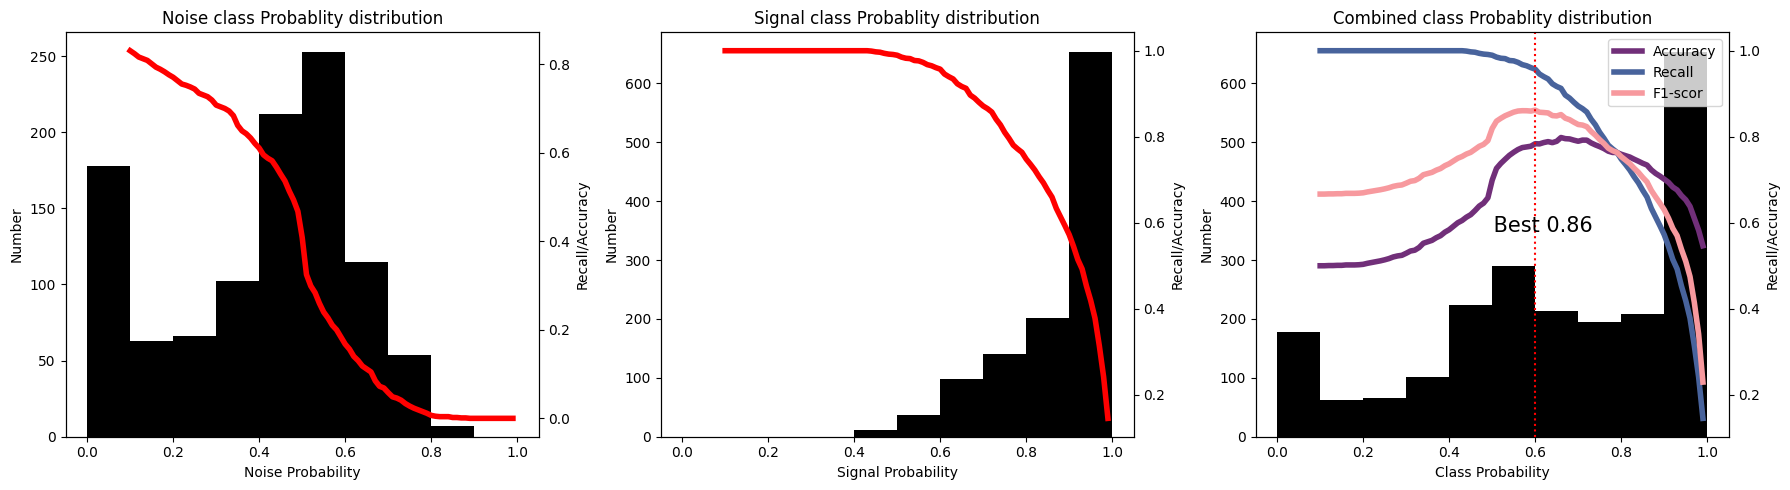

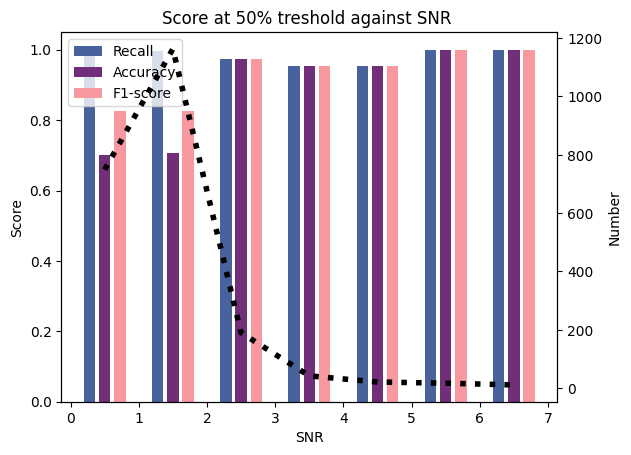

(<Figure size 640x480 with 2 Axes>, <Figure size 1800x500 with 6 Axes>)

In [91]:
plotprobs(pred_list,labels)

## EQTransformer

In [93]:
# Load the pre-trained model
print(EQTransformer.list_pretrained())
model = EQTransformer.from_pretrained("original")
model.to('cpu:0')


['ethz', 'geofon', 'instance', 'iquique', 'lendb', 'neic', 'obs', 'original', 'original_nonconservative', 'scedc', 'stead', 'volpick']


EQTransformer(
  (encoder): Encoder(
    (convs): ModuleList(
      (0): Conv1d(3, 8, kernel_size=(11,), stride=(1,), padding=(5,))
      (1): Conv1d(8, 16, kernel_size=(9,), stride=(1,), padding=(4,))
      (2): Conv1d(16, 16, kernel_size=(7,), stride=(1,), padding=(3,))
      (3): Conv1d(16, 32, kernel_size=(7,), stride=(1,), padding=(3,))
      (4): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (5): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (6): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    )
    (pools): ModuleList(
      (0-6): 7 x MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (res_cnn_stack): ResCNNStack(
    (members): ModuleList(
      (0-3): 4 x ResCNNBlock(
        (dropout): SpatialDropout1d(
          (dropout): Dropout2d(p=0.1, inplace=False)
        )
        (norm1): BatchNorm1d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
        (conv1): Conv1d(

In [94]:
%autoawait on
pred_list = []
for i in tqdm(range(len(dataset))):
    preds = model.annotate(dataset[i][0])
    pred_list.append(max(preds[0].data) )

pred_list = np.array(pred_list)

100%|██████████| 2193/2193 [02:03<00:00, 17.77it/s]


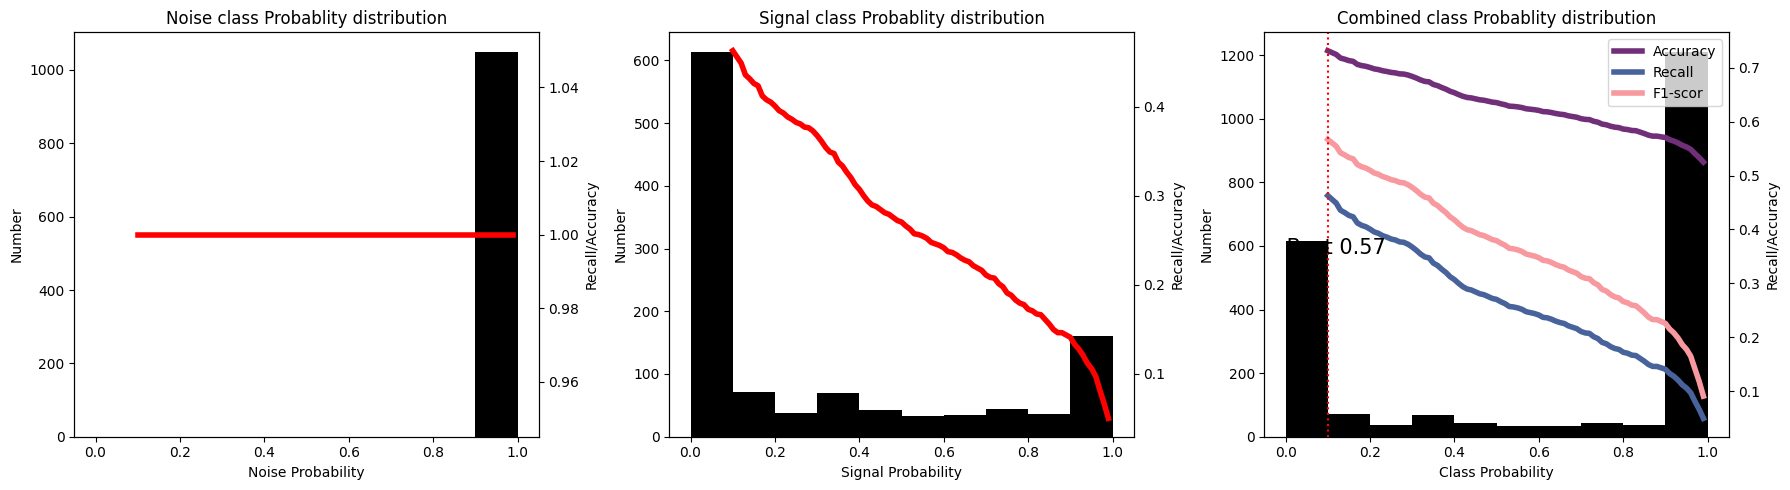

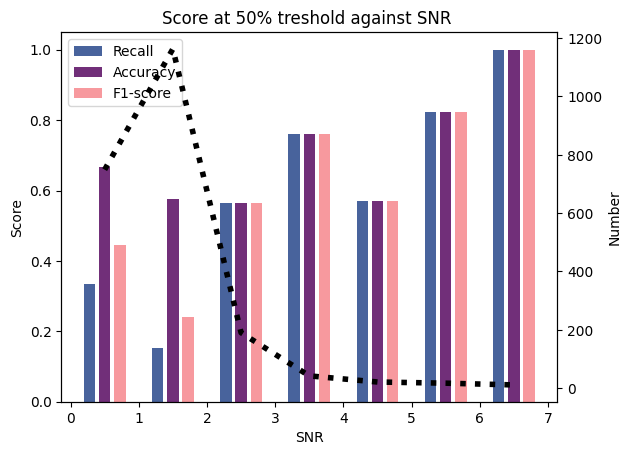

(<Figure size 640x480 with 2 Axes>, <Figure size 1800x500 with 6 Axes>)

In [95]:
plotprobs(pred_list,labels)

## GPD

In [96]:
## # Load the pre-trained PhaseNet model
print(GPD.list_pretrained())
model = GPD.from_pretrained("original")
model.to('cpu:0')

['dummy', 'ethz', 'geofon', 'instance', 'iquique', 'lendb', 'neic', 'original', 'scedc', 'stead']


GPD(
  (conv1): Conv1d(3, 32, kernel_size=(21,), stride=(1,), padding=(10,))
  (bn1): BatchNorm1d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(32, 64, kernel_size=(15,), stride=(1,), padding=(7,))
  (bn2): BatchNorm1d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(64, 128, kernel_size=(11,), stride=(1,), padding=(5,))
  (bn3): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv1d(128, 256, kernel_size=(9,), stride=(1,), padding=(4,))
  (bn4): BatchNorm1d(256, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=6400, out_features=200, bias=True)
  (bn5): BatchNorm1d(200, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=200, out_features=200, bias=True)
  (bn6): BatchNorm1d(200, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=200, out_featu

In [97]:
%autoawait on

pred_list = []
for i in tqdm(range(len(dataset))):
    preds = model.annotate(dataset[i][0])
    pred_list.append(max(preds[0].data) )

pred_list = np.array(pred_list)

100%|██████████| 2193/2193 [10:20<00:00,  3.53it/s]


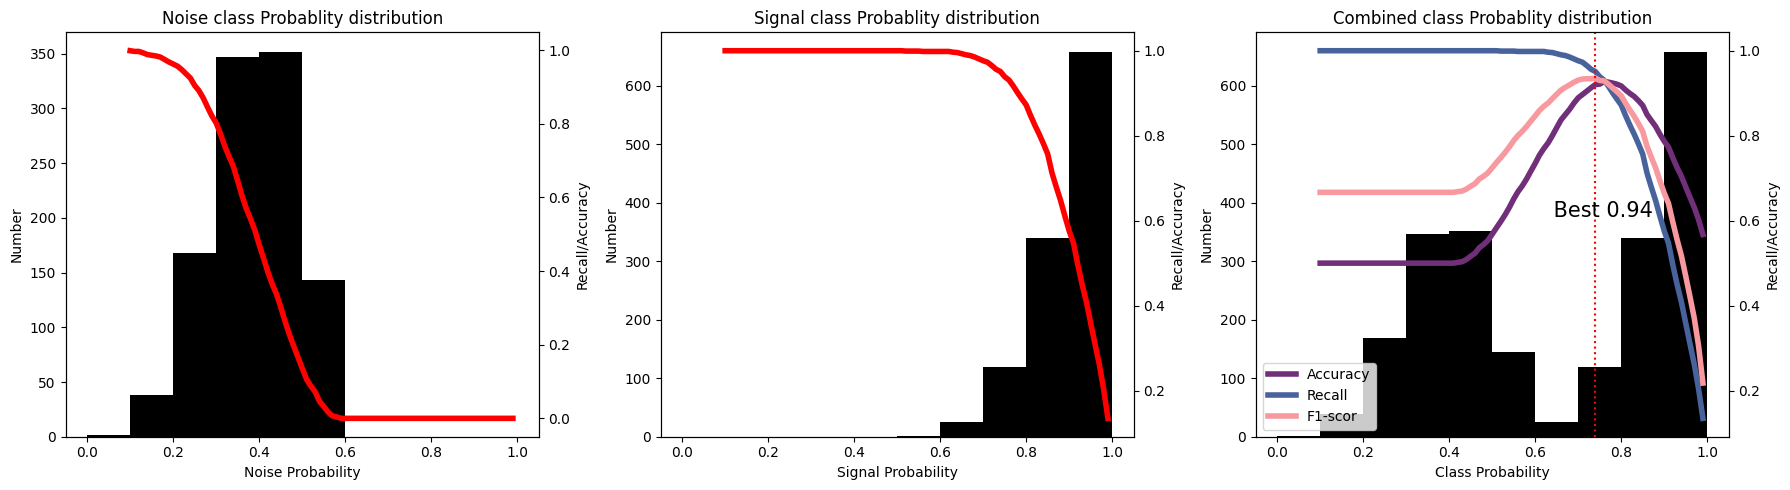

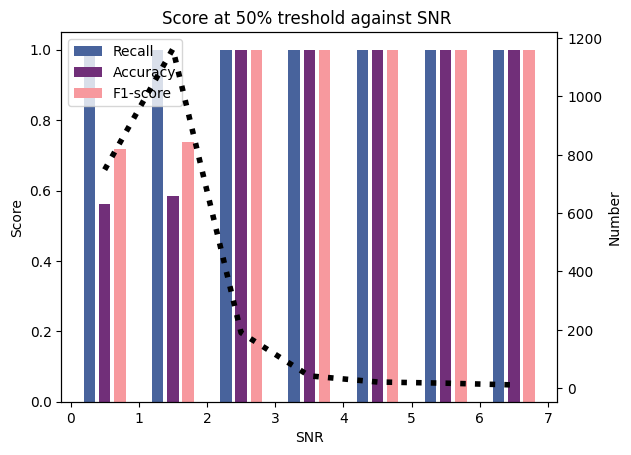

(<Figure size 640x480 with 2 Axes>, <Figure size 1800x500 with 6 Axes>)

In [98]:
plotprobs(pred_list,labels)

## PhaseNet

In [99]:
# Load the pre-trained PhaseNet model
print(PhaseNet.list_pretrained())
model = PhaseNet.from_pretrained("original")
model.to('cpu:0')


['diting', 'ethz', 'geofon', 'instance', 'iquique', 'jma', 'jma_wc', 'lendb', 'neic', 'obs', 'original', 'phasenet_sn', 'pisdl', 'scedc', 'stead', 'volpick']


PhaseNet(
  (inc): Conv1d(3, 8, kernel_size=(7,), stride=(1,), padding=same)
  (in_bn): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (down_branch): ModuleList(
    (0): ModuleList(
      (0): Conv1d(8, 8, kernel_size=(7,), stride=(1,), padding=same, bias=False)
      (1): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): Conv1d(8, 8, kernel_size=(7,), stride=(4,), padding=(3,), bias=False)
      (3): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ModuleList(
      (0): Conv1d(8, 16, kernel_size=(7,), stride=(1,), padding=same, bias=False)
      (1): BatchNorm1d(16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): Conv1d(16, 16, kernel_size=(7,), stride=(4,), bias=False)
      (3): BatchNorm1d(16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (2): ModuleList(
      (0): Conv1d(16, 32, kernel_size=(7,), stride=(1,

In [100]:
%autoawait on
pred_list = []
for i in tqdm(range(len(dataset))):
    preds = model.annotate(dataset[i][0])
    pred_list.append(max(preds[0].data) )

pred_list = np.array(pred_list)

100%|██████████| 2193/2193 [01:20<00:00, 27.22it/s]


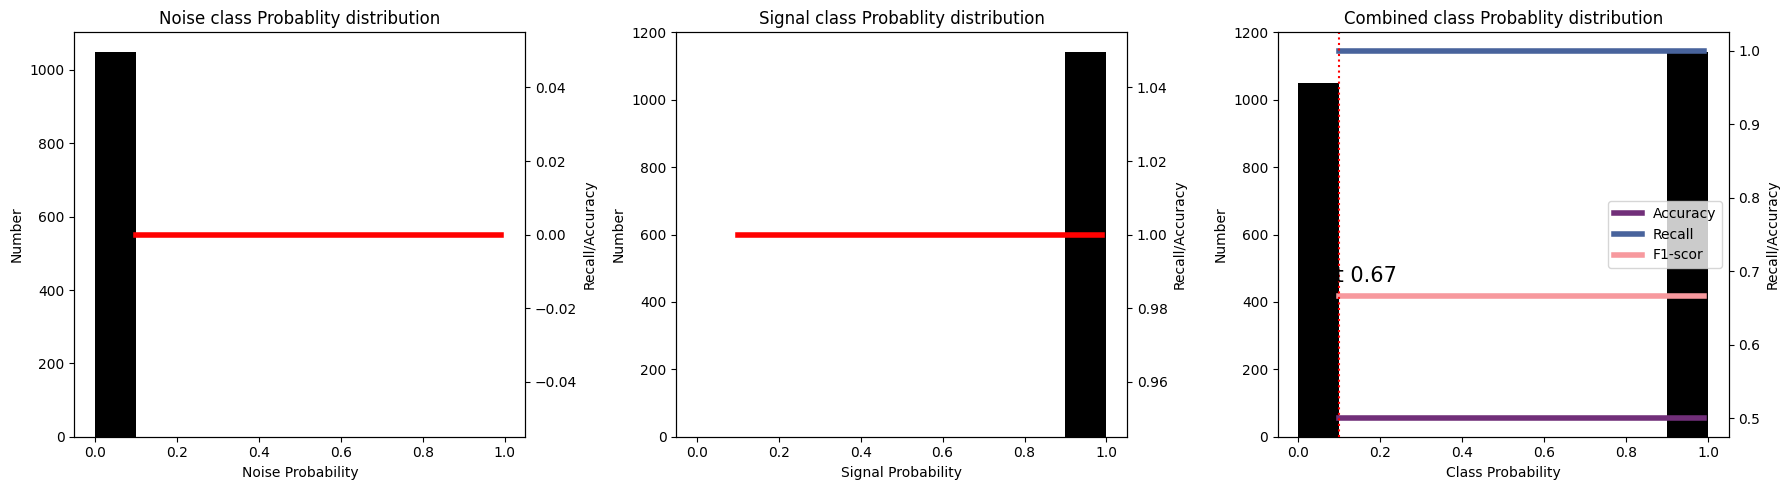

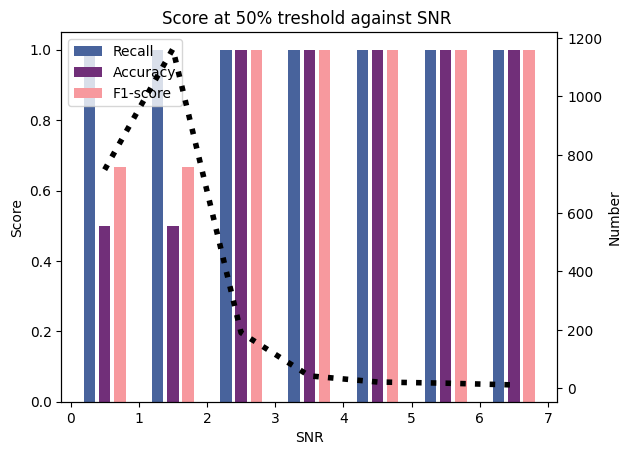

(<Figure size 640x480 with 2 Axes>, <Figure size 1800x500 with 6 Axes>)

In [101]:
plotprobs(pred_list,labels)

## OBSTransformer

In [102]:
# Load the pre-trained model
print(OBSTransformer.list_pretrained())
model = OBSTransformer.from_pretrained("obst2024")
model.to('cpu:0')

['obst2024']


OBSTransformer(
  (encoder): Encoder(
    (convs): ModuleList(
      (0): Conv1d(3, 8, kernel_size=(11,), stride=(1,), padding=(5,))
      (1): Conv1d(8, 16, kernel_size=(9,), stride=(1,), padding=(4,))
      (2): Conv1d(16, 16, kernel_size=(7,), stride=(1,), padding=(3,))
      (3): Conv1d(16, 32, kernel_size=(7,), stride=(1,), padding=(3,))
      (4): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (5): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (6): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    )
    (pools): ModuleList(
      (0-6): 7 x MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (res_cnn_stack): ResCNNStack(
    (members): ModuleList(
      (0-3): 4 x ResCNNBlock(
        (dropout): SpatialDropout1d(
          (dropout): Dropout2d(p=0.2, inplace=False)
        )
        (norm1): BatchNorm1d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
        (conv1): Conv1d

In [103]:
%autoawait on
pred_list = []
for i in tqdm(range(len(dataset))):
    preds = model.annotate(dataset[i][0])
    pred_list.append(max(preds[0].data) )

pred_list = np.array(pred_list)

100%|██████████| 2193/2193 [02:51<00:00, 12.82it/s]


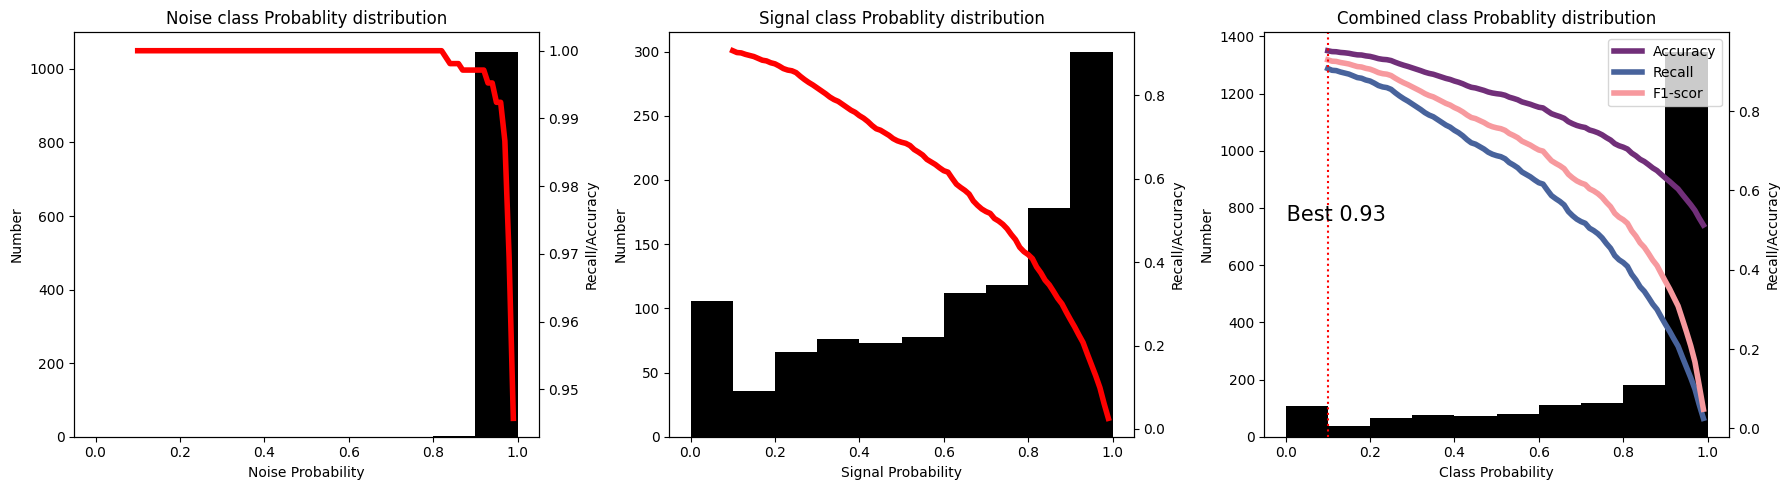

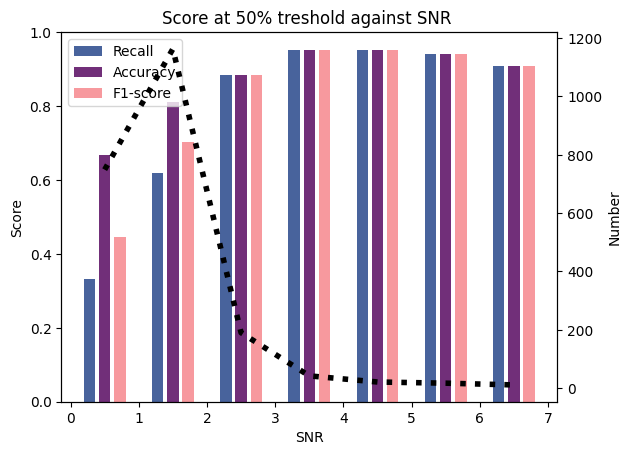

(<Figure size 640x480 with 2 Axes>, <Figure size 1800x500 with 6 Axes>)

In [104]:
plotprobs(pred_list,labels)

# TESTING IsAE

In [21]:
# Initialize the dataset For Natural Trained Earthquakes
dataset_IsAE = CustomWaveformDataset_IsAE(paths, labels, times, waveforms,Spectrogram)

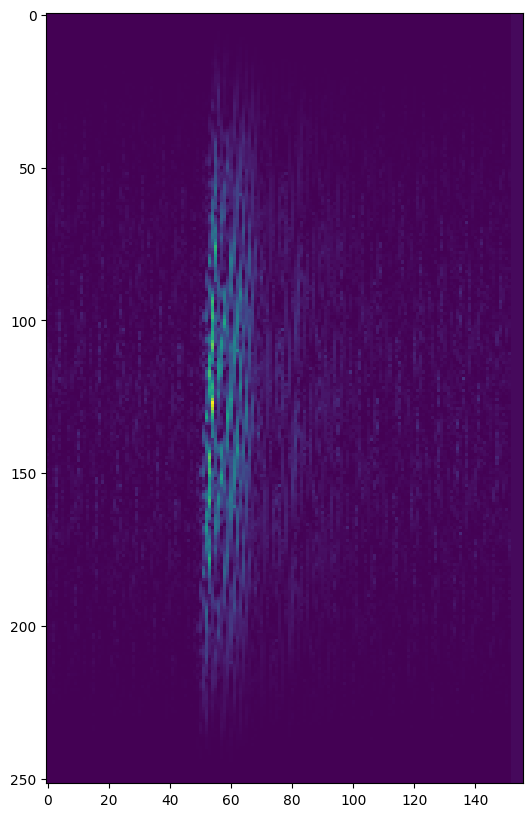

In [50]:
plt.figure(figsize=(8,16))
plt.imshow(Spectrogram[0][0])
plt.show()

In [24]:
device = 'cpu:0'
model = torch.jit.load(f'Classifier_vVOS_AVGPOOL_5_40.pt',map_location=device).to(device)

for param in model.encoder.parameters():
    param.requires_grad = False

model.eval()

RecursiveScriptModule(
  original_name=Classifier
  (encoder): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Conv2d)
    (1): RecursiveScriptModule(original_name=ReLU)
    (2): RecursiveScriptModule(original_name=Conv2d)
    (3): RecursiveScriptModule(original_name=ReLU)
    (4): RecursiveScriptModule(original_name=Conv2d)
    (5): RecursiveScriptModule(original_name=ReLU)
    (6): RecursiveScriptModule(original_name=Conv2d)
    (7): RecursiveScriptModule(original_name=ReLU)
    (8): RecursiveScriptModule(original_name=Conv2d)
    (9): RecursiveScriptModule(original_name=ReLU)
    (10): RecursiveScriptModule(original_name=Conv2d)
  )
  (classify): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Linear)
    (1): RecursiveScriptModule(original_name=ReLU)
    (2): RecursiveScriptModule(original_name=Linear)
    (3): RecursiveScriptModule(original_name=ReLU)
    (4): RecursiveScriptModule(or

In [49]:
prob = []
for data in tqdm(dataset_IsAE):
    with torch.no_grad(): 
        img, y_true = data
        img = img.unsqueeze(0).to(device).float()
        logits = model(img)
        p = logits.cpu().numpy()
        prob.append(logits[0][0].cpu())
pred_list = np.array(prob)    

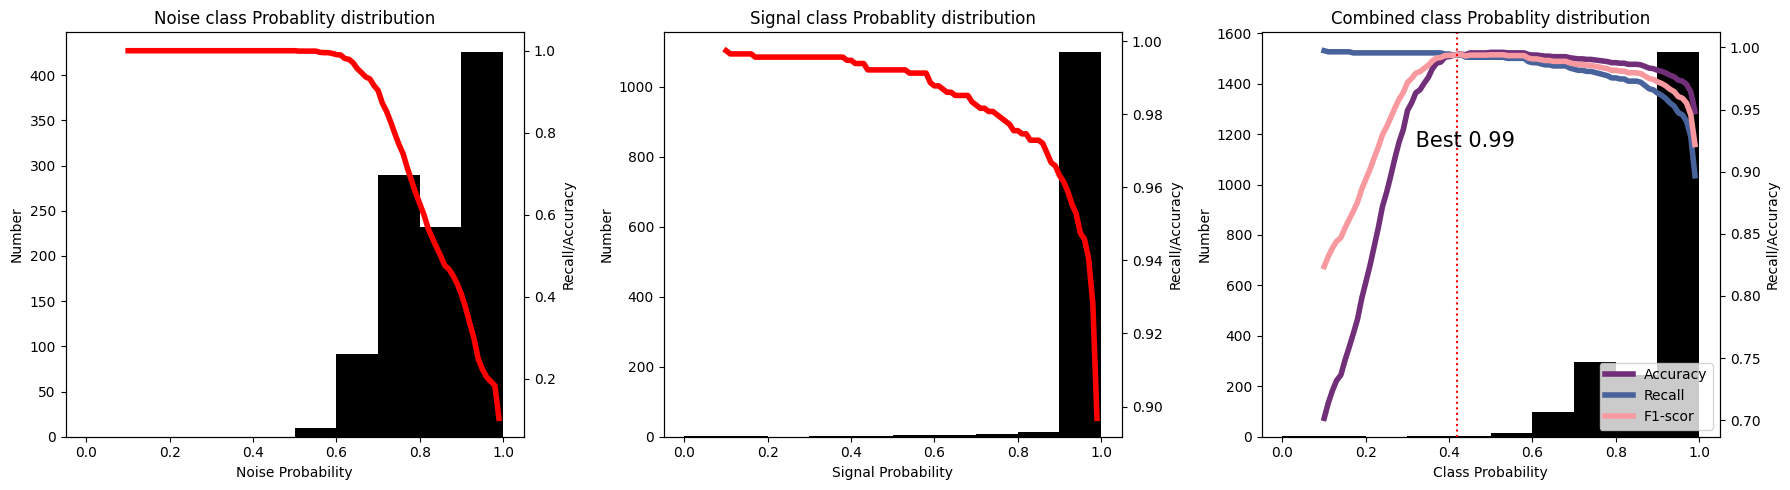

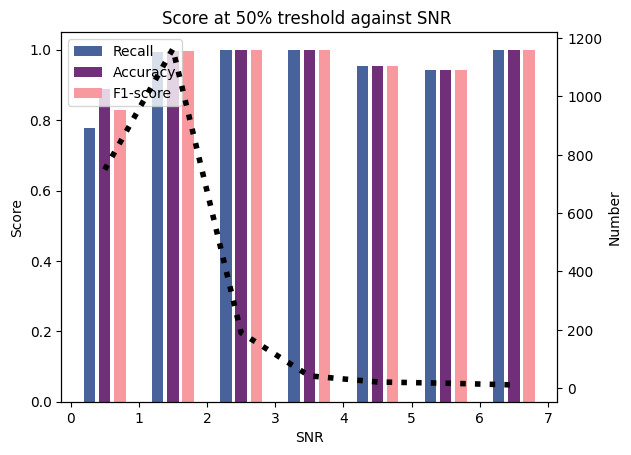

(<Figure size 640x480 with 2 Axes>, <Figure size 1800x500 with 6 Axes>)

In [83]:
plotprobs(pred_list,labels)